Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Import Machine Learning Tools

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Create the Dataset

In [3]:
data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks": [35, 40, 45, 50, 55, 60, 68, 72, 80, 88]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Marks
0,1,35
1,2,40
2,3,45
3,4,50
4,5,55
5,6,60
6,7,68
7,8,72
8,9,80
9,10,88


Create Classification Labels

In [4]:
df["Result"] = np.where(df["Marks"] >= 50, 1, 0)

df

,Hours_Studied,Marks,Result
0,1,35,0
1,2,40,0
2,3,45,0
3,4,50,1
4,5,55,1
5,6,60,1
6,7,68,1
7,8,72,1
8,9,80,1
9,10,88,1


Here:

1 means Pass

0 means Fail

Explore the Dataset

In [5]:
print("Shape:", df.shape)
print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

Shape: (10, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours_Studied  10 non-null     int64
 1   Marks          10 non-null     int64
 2   Result         10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes

Descriptive Statistics:


,Hours_Studied,Marks,Result
count,10.00000,10.000000,10.000000
mean,5.50000,59.300000,0.700000
std,3.02765,17.518562,0.483046
min,1.00000,35.000000,0.000000
25%,3.25000,46.250000,0.250000
50%,5.50000,57.500000,1.000000
75%,7.75000,71.000000,1.000000
max,10.00000,88.000000,1.000000


Visualize the Classes

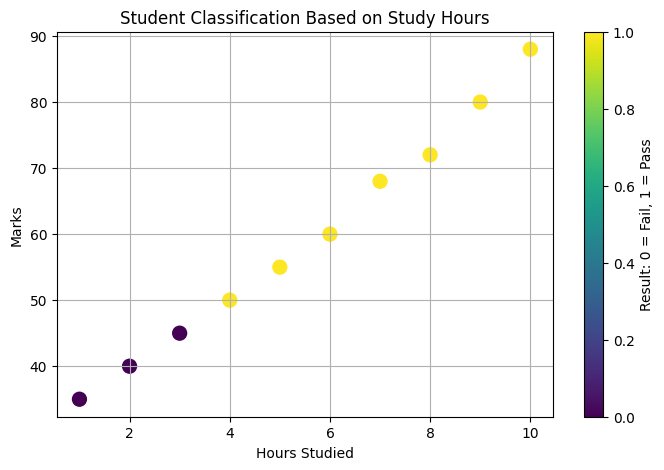

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours_Studied"],
    df["Marks"],
    c=df["Result"],
    cmap="viridis",
    s=100
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Student Classification Based on Study Hours")
plt.colorbar(label="Result: 0 = Fail, 1 = Pass")
plt.grid(True)
plt.show()

Select Features and Target

In [7]:
X = df[["Hours_Studied"]]
y = df["Result"]

print("Features:")
display(X)

print("Target:")
display(y)

Features:


,Hours_Studied
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


Target:


,Result
0,0
1,0
2,0
3,1
4,1
5,1
6,1
7,1
8,1
9,1


Split the Dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


Train Logistic Regression

In [9]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression predictions:", logistic_predictions)

Logistic Regression predictions: [1 1]


Evaluate Logistic Regression

In [10]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions, zero_division=0))

Logistic Regression Accuracy: 50.0 %

Confusion Matrix:
[[0 1]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



Train Decision Tree

In [11]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree predictions:", tree_predictions)

Decision Tree predictions: [0 1]


Evaluate Decision Tree

In [12]:
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_predictions))

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions, zero_division=0))

Decision Tree Accuracy: 100.0 %

Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



Compare Both Models

In [13]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        logistic_accuracy * 100,
        tree_accuracy * 100
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,50.0
1,Decision Tree,100.0


Visualize Accuracy Comparison

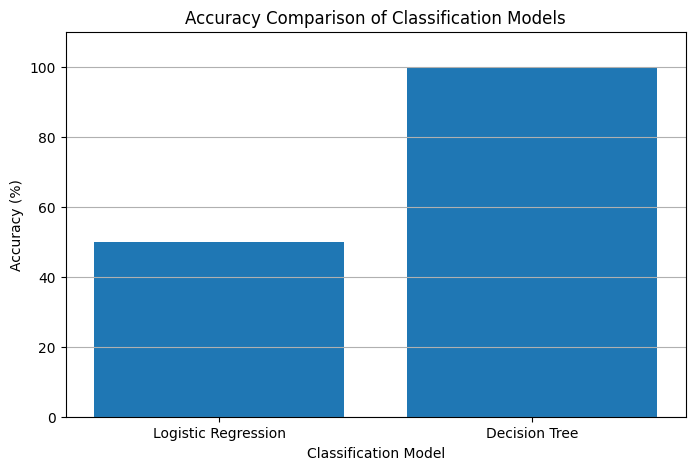

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.xlabel("Classification Model")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Classification Models")
plt.ylim(0, 110)
plt.grid(axis="y")
plt.show()

Predict a New Student Result

In [15]:
new_student = pd.DataFrame({
    "Hours_Studied": [7]
})

logistic_result = logistic_model.predict(new_student)[0]
tree_result = tree_model.predict(new_student)[0]

print("Logistic Regression Prediction:",
      "Pass" if logistic_result == 1 else "Fail")

print("Decision Tree Prediction:",
      "Pass" if tree_result == 1 else "Fail")

Logistic Regression Prediction: Pass
Decision Tree Prediction: Pass


Final Observations

In [16]:
print("Final Model Comparison")
print("-" * 30)

print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")
print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

if logistic_accuracy > tree_accuracy:
    print("Logistic Regression performed better on the test data.")
elif tree_accuracy > logistic_accuracy:
    print("Decision Tree performed better on the test data.")
else:
    print("Both models achieved the same accuracy on the test data.")

print("\nThe models classified students into Pass and Fail categories.")

Final Model Comparison
------------------------------
Logistic Regression Accuracy: 50.00%
Decision Tree Accuracy: 100.00%
Decision Tree performed better on the test data.

The models classified students into Pass and Fail categories.


“Decision Tree performed better on the test data.”